In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import r3b
import math
import ROOT
import seaborn as sns

%jsroot off

In [2]:
def gaussian(x, mu, sig, amp):
    return amp * np.exp(-np.power(x - mu, 2.0) / (2 * np.power(sig, 2.0)))

## Problems to solve

* Does parameter shift with time? Try with different event numbers
* Does the error come from the muon track inclination? (❌)


In [83]:
root_path = "/lustre/r3b/ywang/test/s122"
dir_path = "test_aug18"

Files:

* hit.test0.root: Data using the old calibration method using muon track reconstruction.
* hit.test1.root: Data using the new millepede calibration method.
* hit.test2.root: Data using the new millepede calibration method, but only with horizontal (along z direction) events.

In [84]:
root_filenames = {"recons": "hit.test0.root", "millepede": "hit.test1.root", "t_sync": "hit.test3.root"}
root_files = {key: ROOT.TFile(f"{root_path}/{dir_path}/{basename}") for key, basename in root_filenames.items()}
root_hist_dirs = {key: root_file.Get("DataMonitor/NeulandHitCosmicMonitorTask") for key, root_file in root_files.items()}

# root_file = ROOT.TFile(f"{root_path}/{dir_path}/hit.test1.root")
# root_hist_dir = root_file.Get("DataMonitor/NeulandHitCosmicMonitorTask")
# root_file_old = ROOT.TFile(f"{root_path}/{dir_path}/hit.test0.root")
# root_hist_dir_old = root_file_old.Get("DataMonitor/NeulandHitCosmicMonitorTask")
# root_hist_dir.ls()

In [85]:
def plot_track_info(hist_dirs):
    fig, axis = plt.subplots(nrows=2, ncols=2, figsize=[10, 8])
    hist_names = [["a_xz", "a_yz"], ["b_xz", "b_yz"]]
    for row_idx, row in enumerate(hist_names):
        for col_idx, hist_name in enumerate(row):
            hists = {name: hist_dir.Get(hist_name) for name, hist_dir in hist_dirs.items()}
            r3b.PlotHist.plot_th1s(hists, axis[row_idx][col_idx])
    fig.tight_layout()
    return fig, axis


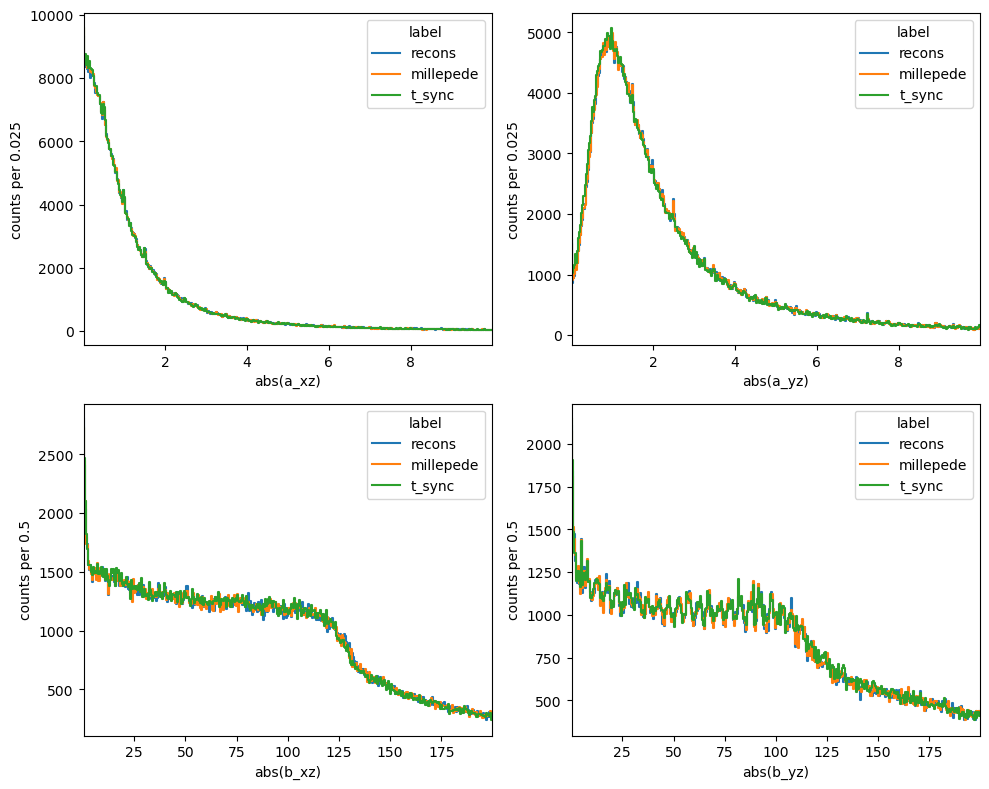

In [86]:
fig, axis = plot_track_info(root_hist_dirs)

In [87]:
def plot_condition(hist_dirs):
    fig, axis = plt.subplots(nrows=1, ncols=2, figsize=[12, 7])
    hist_names = ["condition_check", "trig_check"]
    for col_idx, hist_name in enumerate(hist_names):
        hists = {name: hist_dir.Get(hist_name) for name, hist_dir in hist_dirs.items()}
        r3b.PlotHist.plot_th1s(hists, axis[col_idx])
        # axis[col_idx].bar_label(axis[col_idx].containers[0], fontsize=10, fmt="{:.2e}");
    for idx in range(len(hist_dirs)):
        axis[0].bar_label(axis[0].containers[idx], fontsize=10);
    axis[1].bar_label(axis[1].containers[0], fontsize=10);
    fig.tight_layout()
    return fig, axis

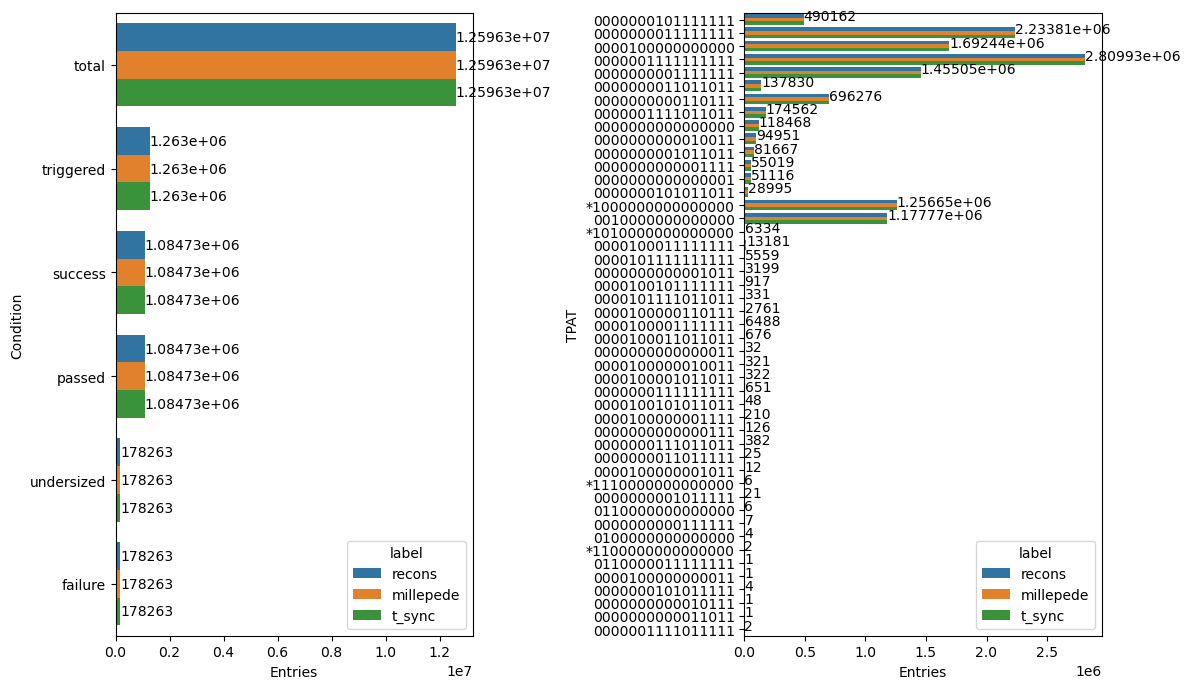

In [88]:
fig, axis = plot_condition(root_hist_dirs)
fig.tight_layout()
# axis[1].tick_params("x", rotation=90)

In [89]:
def plot_value_diff(hist_dirs):
    fig, axis = plt.subplots(nrows=len(hist_dirs), ncols=1, figsize=[15, 5], sharex=True)
    hist_name = "fit_diff_time"
    for idx, (name, hist_dir) in enumerate(hist_dirs.items()):
        hist = hist_dir.Get(hist_name)
        im = r3b.PlotHist.plot_th2(hist, axis[idx])
        colorbar = fig.colorbar(im, ax=axis[idx], location="right", pad=0.01, fraction=0.05)
        # colorbar.ax.set_ylim(0, 200)
        axis[idx].set_title(f"Residuals for {name}")
    axis[0].set_xlabel("")
    return fig, axis

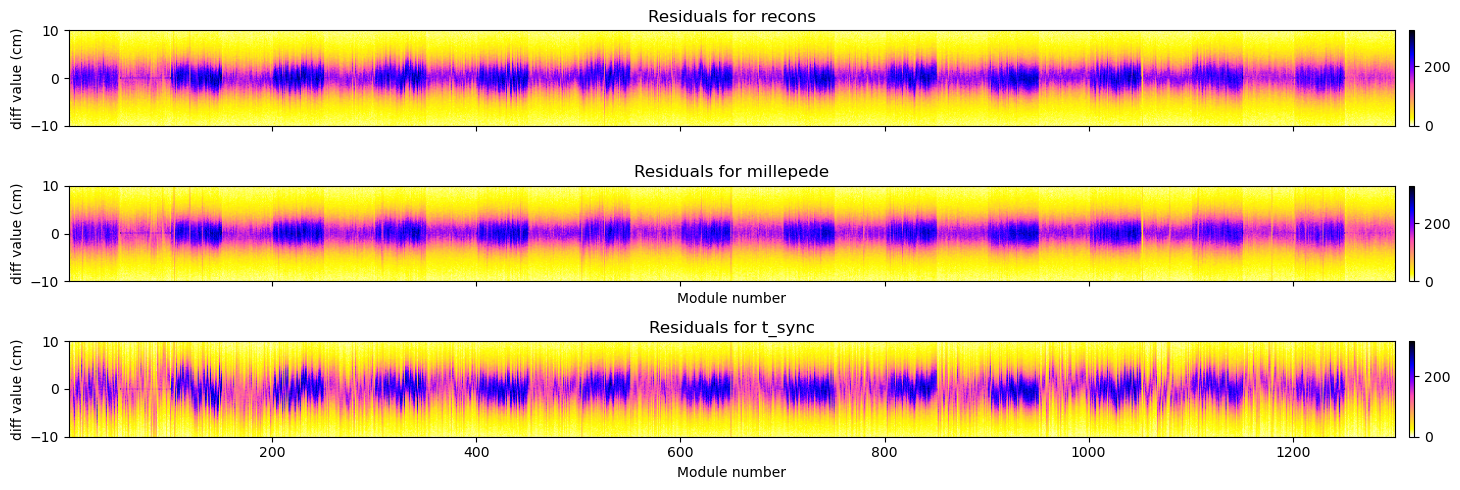

In [90]:
fig, axis = plot_value_diff(root_hist_dirs)
xmin, xmax = (1200, 1250)
ymin, ymax = (-10, 10)
for ax in axis:
    ax.set_ylim(ymin, ymax)
# axis[0].set_xlim(xmin, xmax)
# axis[1].set_xlim(xmin, xmax)
fig.tight_layout()

In [34]:
def fit_th1(hist):
    res = hist.Fit("gaus", "SQ", "", -5, 5)
    return {"mean": res.Parameter(1), "std": res.Parameter(2), "amp": res.Parameter(0) , "pvalue": res.Prob()}

def make_gaussian_df(pars, xmin, xmax, num):
    xs = np.linspace(start=xmin, stop=xmax, num=num)
    ys = gaussian(xs, pars["mean"], pars["std"], pars["amp"])
    return pd

In [99]:
def slice_view(hist_dirs, module_num : list[int]):
    one_plot_height = 5
    fig, axes = plt.subplots(nrows=math.ceil(len(module_num)/2), ncols=2, figsize=[one_plot_height * 3 , len(module_num) /2 * one_plot_height])
    hist_name = "fit_diff_time"
    for idx, module_n in enumerate(module_num):
        dfs = []
        axis = axes[math.floor(idx/2)][idx%2]
        for key, hist_dir in hist_dirs.items():
            hist = hist_dir.Get(hist_name)
            proj_y = hist.ProjectionY("_py", module_n, module_n)
            proj_y.Scale(1/proj_y.Integral())
            df = r3b.th1d_to_df(proj_y)
            df["label"] = key
            dfs.append(df)
        all_df = pd.concat(dfs)
        sns.lineplot(all_df, x="x", y="y", hue="label", ax=axis, linewidth=1)
        axis.axvline(x=0, color='r')
        axis.set_xlabel("Diff (cm)")
        axis.set_ylabel("fraction (%)")
        axis.set_title(f"module num {module_n}")
    return fig, axes

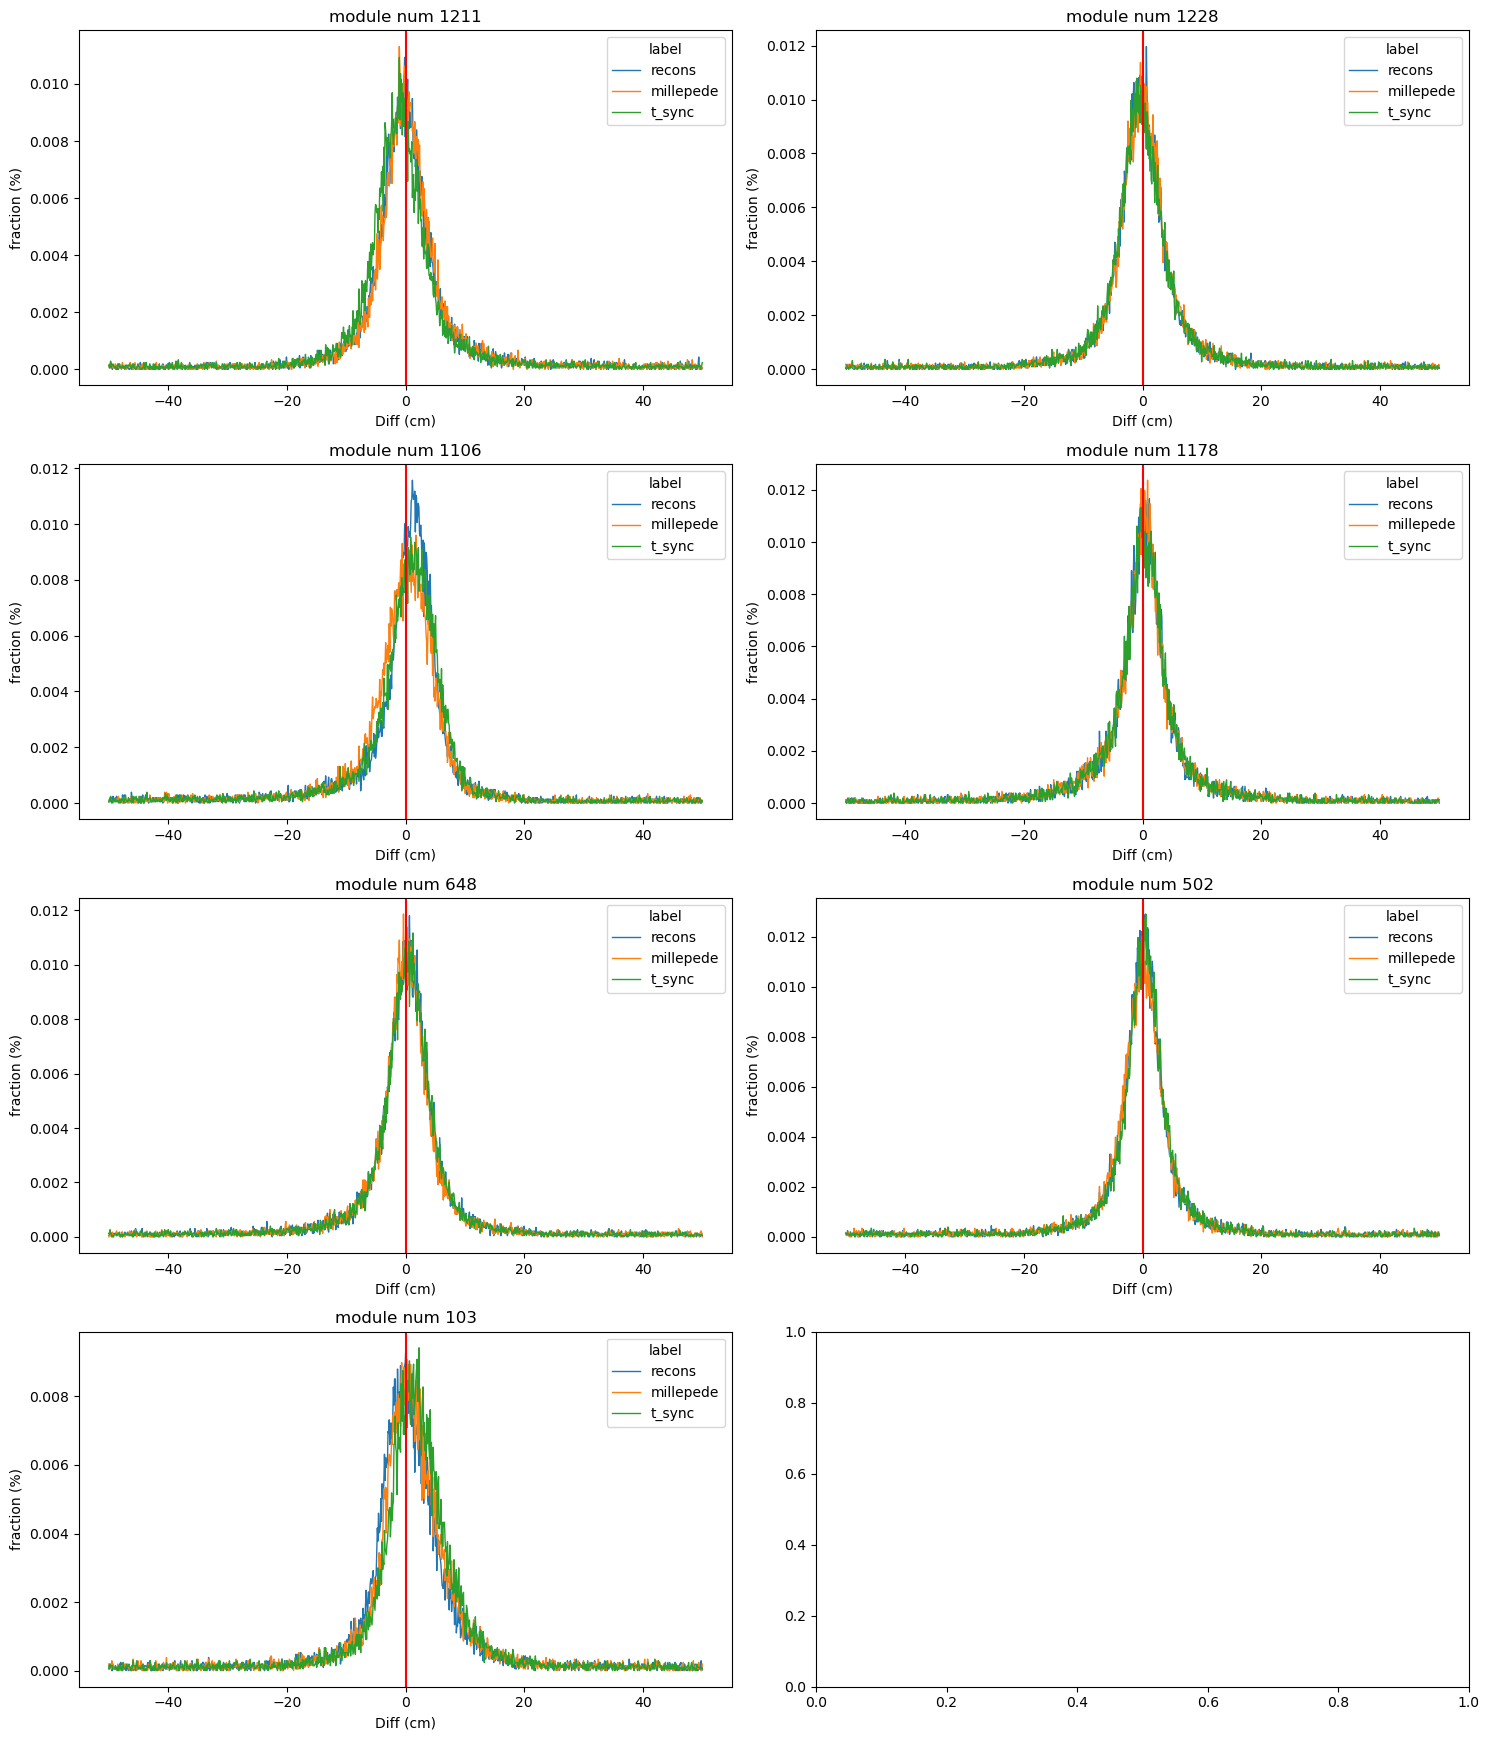

In [100]:
# bar_num = 1052
bar_num = 627
outliers = [1211, 1228, 1106, 1178, 648, 502, 103]
# fig, axis = slice_view(root_hist_dirs, [627, 1052])
fig, axis = slice_view(root_hist_dirs, outliers)
# fig, axis = slice_view({"millepede":root_hist_dir}, 504)
fig.tight_layout()